## <span style="color:#eed699">Quest 2: How Quack Echoes Back</span>

![Header image](./images/q2_header_image.svg)
[<img src="./images/instagram.svg" alt="My SVG" width="25" height="25">
<span style="color:lime">Monika Lipińska</span>](https://www.instagram.com/monli_art/)

### <span style="color:#eed699">Part I</span>

> ## <span style="color:#eed699"> <img src='./images/book.svg' height=40 width=40 style="display:inline-block height:fit-content;vertical-align: middle; margin: 5px; ">Story section</span>
>
> Another feature of the dragonduck’s unusual singing is its ability to control sound. A simple “quack!” or a whistle are not the only sounds it can make. The mechanism that controls pitch can copy the sound of a piano, a glockenspiel, or almost any other sound that the dragonduck hears.
>
> Before the sound leaves the beak, it resonates in a special way. It bounces off the vocal bones, which the dragonduck can adjust to get the result it wants. These structures act like a template used to build the sound.
>
> <br/>

Veronica shows you a slightly simplified version of this mechanism so it is easier to understand. The sound template can be imagined as **an infinite grid extending in all directions**, with a sound source `@` and vocal bones `#`.

The sound source emits a sound wave that moves according to a fixed sequence of moves, repeated forever: `↑ → ↓ ←`. So the sound wave tries to change direction as follows: up, right, down, left, up, right, down, left, and so on, however, it must create a continuous stream of air. If the next move in the sequence would take it to a place where the sound wave already exists, that move is skipped and the next one is tried.

As a result, the stream of sound wraps around the source like a spiral. The first few steps of how this stream is formed are shown below. The sound source and the head of the sound wave are marked with `@`, and the other sound wave segments are marked with `+`. Each step has also the next possible move from the sequence wrapped with `[ ]`.

<pre style="border: 0.1pt solid DimGray;border-radius: 5px;padding:1rem;width: max-content;">
Step: 0         Step: 1         Step: 2         Step: 3         Step: 4
Next: [↑]→↓←    Next: ↑[→]↓←    Next: ↑→[↓]←    Next: ↑[→]↓←    Next: ↑→[↓]←
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........
...........     .....@.....     .....+@....     .....++....     .....++....
.....@.....     .....+.....     .....+.....     .....+@....     .....++@...
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........

Step: 5         Step: 6         Step: 7         Step: 8         Step: 9
Next: ↑→↓[←]    Next: ↑→[↓]←    Next: ↑→↓[←]    Next: [↑]→↓←    Next: ↑→↓[←]
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........
.....++....     .....++....     .....++....     .....++....     .....++....
.....+++...     .....+++...     .....+++...     .....+++...     .....+++...
.......@...     ......@+...     ......++...     ......++...     .....@++...
...........     ...........     ......@....     .....@+....     .....++....
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........

Step: 10        Step: 11        Step: 12
Next: [↑]→↓←    Next: ↑→↓[←]    Next: ↑→↓←
...........     ...........     ...........
...........     ...........     ...........
...........     ...........     ...........
.....++....     .....++....     .....++....
.....+++...     ....@+++...     ...@++++...
....@+++...     ....++++...     ....++++...
.....++....     .....++....     .....++....
...........     ...........     ...........
...........     ...........     ...........
...........     ...........     ...........
</pre>

The first three steps follow the sequence: up, right, down, without any obstacles. After step number `3`, the direction ‘left’ cannot be performed, because the target cell contains the sound wave. The next instruction, ‘up’ is also not possible, as the air stream is already there. The following direction, ‘right’, can be performed without any issues. Similar situations, where some sequence steps must be skipped, also occur after steps `6`, `9`, and `11`.

The air stream continues to develop until it reaches the vocal bone segment `#`. To test your understanding in practice, Veronica suggests an exercise: find the number of steps it takes for the air stream to reach the vocal bone `#`.

**Example based on the following notes:**

<pre style="border: 2px dotted lime;border-radius: 5px;padding:1rem;width: max-content;">
.......
.......
.......
.#.@...
.......
.......
.......
</pre>

Looking at the example steps shown in the description above, we can see that the vocal bone is located at a position reached by the air stream after <code style="color:white"> 12</code> steps, which would be the correct answer for this example.

<span style="color:#eed699">After how many steps will the sound reach the vocal bone in the template?<span>


In [50]:
import re

from matplotlib.colors import ListedColormap
import numpy as np
from matplotlib import pyplot as plt
from more_itertools import first
from test_utilities import test
from util import Str

test_cases = [
    # cSpell:disable
    {
        'name': 'Example I',
        'notes': """
            .......
            .......
            .......
            .#.@...
            .......
            .......
            .......
         """,
        'expected': 12,
    },
    # cSpell:enable
]

type Pos = tuple[int, int]


class SoundTemplate(Str):
    POSSIBLE_STEPS = (-1, 0), (0, 1), (1, 0), (0, -1)

    def __init__(self, notes: str) -> None:
        grid = re.findall(r'[\.#@]+', notes)
        self.source = self.get_pos(grid, '@')
        self.bones = self.get_all(grid, '#')

    def steps_sound_reach_vocal_bone(self, debug: bool) -> int:
        current = self.source
        steps, next_step = 0, 0
        seen = {current}

        bone = first(self.bones)

        while current != bone:
            if debug:
                self.debug(current, seen, next_step, steps)

            current = self.next_pos(current, next_step)
            seen.add(current)
            next_step = (next_step + 1) % len(self.POSSIBLE_STEPS)

            while self.next_pos(current, next_step) in seen:
                next_step = (next_step + 1) % len(self.POSSIBLE_STEPS)

            steps += 1

        if debug:
            self.debug(current, seen, next_step, steps)

        return steps

    def next_pos(self, current: Pos, next_step: int) -> Pos:
        i, j = current
        di, dj = self.POSSIBLE_STEPS[next_step]
        return i + di, j + dj

    def get_all(self, grid, symbol: str) -> set[Pos]:
        return {
            (i, j) for i in range(len(grid)) for j in range(len(grid[0])) if grid[i][j] == symbol
        }

    def get_pos(self, grid, symbol: str) -> Pos:
        return first(
            (i, j) for i in range(len(grid)) for j in range(len(grid[0])) if grid[i][j] == symbol
        )

    def debug(
        self, current: Pos, seen: set[Pos], next_step: int, steps: int, delta: int = 4
    ) -> None:
        def pos_str(i: int, j: int) -> str:
            if (i, j) == current:
                return '@'
            if (i, j) in self.bones:
                return '#'
            if (i, j) in seen:
                return '+'
            return '.'

        symbols = {(-1, 0): '↑', (0, 1): '→', (1, 0): '↓', (0, -1): '←'}

        # next_str = ['[↑]→↓←', '↑[→]↓←', '↑→[↓]←', '↑→↓[←]']
        next_str = ''.join(
            f'{symbols[self.POSSIBLE_STEPS[i]]}'
            if i != next_step
            else f'[{symbols[self.POSSIBLE_STEPS[i]]}]'
            for i in range(len(self.POSSIBLE_STEPS))
        )
        buffer = [' ' * 4 + f'Step: {steps}', ' ' * 4 + f'Next: {next_str}']

        points = seen | self.bones
        fr_row = min(i for i, _ in points) - delta
        to_row = max(i for i, _ in points) + delta + 1

        fr_col = min(j for _, j in points) - delta
        to_col = max(j for _, j in points) + delta + 1

        grid = '\n'.join(
            f'{i:4d}' + ''.join(pos_str(i, j) for j in range(fr_col, to_col))
            for i in range(fr_row, to_row)
        )
        buffer.append(grid)
        buffer.append(' ' * 4 + ''.join(str(abs(j) % 10) for j in range(fr_col, to_col)))
        buffer.append(
            ' ' * 4
            + ''.join(
                str(abs(j) // 10 % 10) if abs(j) % 10 == 0 else ' ' for j in range(fr_col, to_col)
            )
        )
        buffer.append(
            ' ' * 4
            + ''.join(
                str(abs(j) // 100 % 10) if abs(j) // 10 % 10 != 0 and abs(j) % 10 == 0 else ' '
                for j in range(fr_col, to_col)
            )
        )

        s = '\n'.join(buffer)
        print(s)
        print()

    def display(self, seen: set[Pos]) -> None:
        # def pos_str(i: int, j: int) -> str:
        #     if (i, j) == current:
        #         return '@'
        #     if (i, j) in self.bones:
        #         return '#'
        #     if (i, j) in seen:
        #         return '+'
        #     return '.'

        points = seen | self.bones
        fr_row = min(i for i, _ in points)
        to_row = max(i for i, _ in points)

        fr_col = min(j for _, j in points)
        to_col = max(j for _, j in points)

        rows = to_row - fr_row + 1
        cols = to_col - fr_col + 1

        # Create a grid with numbers 0–9 repeating
        grid = np.zeros((rows, cols), dtype=int)

        for r, c in seen:
            grid[r, c] = 1

        for r, c in self.bones:
            grid[r, c] = 2

        cmap = ListedColormap(['black', 'grey', 'green'])
        # Display the grid
        plt.imshow(grid, cmap=cmap, origin='upper')
        plt.axis('off')
        plt.show()


@test(tests=test_cases[:])
def partI(notes: str, debug: bool = False) -> int:
    st = SoundTemplate(notes)
    return st.steps_sound_reach_vocal_bone(debug)


Test Example I passed, for partI.
Success


In [51]:
with open('./inputs/everybody_codes_e3_q02_p1.txt') as f:
    notes1 = f.read()

print(f'Part I: {partI(notes1)}')

Part I: 282


## <span style="color:#eed699">Part II</span>

In the real process of sound propagation, **all vocal bones <code style="color:white;border: 0.1pt solid DimGray;border-radius: 5px;padding:0.1rem 0.4rem;width: max-content;"> #</code> are treated as obstacles** in the same way as the existing sound wave.

Additionally, the sound wave spreads instantly in areas that are completely surrounded on all sides. For example, in a hypothetical situation like the one shown below:

<pre style="border: 0.1pt solid DimGray;border-radius: 5px;padding:1rem;width: max-content;">
++++++....             ++++++....
++++++....             ++++++....
++++++++..             ++++++++..
++++..++@.             ++++..+++.
++........       >     ++......@.
++++..++..             ++++..++..
+++++++...             +++++++...
++++++....             ++++++....
++++++....             ++++++....
</pre>

the <code style="border: 0.1pt solid DimGray;border-radius: 5px;padding:0.1rem 0.4rem;width: max-content;">.</code> grid cells to the left of the sound wave head are surrounded and they instantly receive the vibrations:

<pre style="border: 0.1pt solid DimGray;border-radius: 5px;padding:1rem;width: max-content;">
++++++....
++++++....
++++++++..
+++++++++.
++++++++@.
++++++++..
++++++++..
++++++....
++++++....
</pre>

The actual goal of the process is not for the sound stream to reach the vocal bone, but to **surround it from all sides**. A vocal bone is considered surrounded if there is no way to escape from it to the outside of the air stream, assuming movement is allowed only to neighbouring cells (not diagonally). The surrounded bone enters the resonance of the air stream, and it is the bone itself that emits the proper whistle or other sound.

The next exercise once again concerns a single vocal bone segment, positioned slightly further away from the source. Your goal is to **find the number of steps after which the sound stream will surround this bone.**

**Example based on the following notes:**

<pre style="border: 2px dotted lime;border-radius: 5px;padding:1rem;width: max-content;">
.......
.......
.......
.#.@...
.......
.......
.......
</pre>

In this case, surrounding the vocal bone takes <code style="color:white;border: 0.1pt solid DimGray;border-radius: 5px;padding:0.1rem 0.4rem;width: max-content;"> 47</code> steps.

The detailed progression of the air stream propagation is shown below.

<pre style="border: 0.1pt solid DimGray;border-radius: 5px;padding:1rem;width: max-content;">
Step: 0         Step: 1         Step: 2         Step: 3         Step: 4         Step: 5
Next: [↑]→↓←    Next: ↑[→]↓←    Next: ↑→[↓]←    Next: ↑[→]↓←    Next: ↑→[↓]←    Next: ↑→↓[←]
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
...........     .....@.....     .....+@....     .....++....     .....++....     .....++....
...#.@.....     ...#.+.....     ...#.+.....     ...#.+@....     ...#.++@...     ...#.+++...
...........     ...........     ...........     ...........     ...........     .......@...
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........

Step: 6         Step: 7         Step: 8         Step: 9         Step: 10        Step: 11
Next: ↑→[↓]←    Next: ↑→↓[←]    Next: [↑]→↓←    Next: ↑→↓[←]    Next: [↑]→↓←    Next: [↑]→↓←
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
.....++....     .....++....     .....++....     .....++....     .....++....     .....++....
...#.+++...     ...#.+++...     ...#.+++...     ...#.+++...     ...#.+++...     ...#@+++...
......@+...     ......++...     ......++...     .....@++...     ....@+++...     ....++++...
...........     ......@....     .....@+....     .....++....     .....++....     .....++....
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........

Step: 12        Step: 13        Step: 14        Step: 15        Step: 16        Step: 17
Next: ↑→↓[←]    Next: [↑]→↓←    Next: ↑[→]↓←    Next: [↑]→↓←    Next: ↑[→]↓←    Next: ↑→[↓]←
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ....@......     ....+@.....
...........     ...........     ...@.......     ...+@......     ...++......     ...++......
....@++....     ...@+++....     ...++++....     ...++++....     ...++++....     ...++++....
...#++++...     ...#++++...     ...#++++...     ...#++++...     ...#++++...     ...#++++...
....++++...     ....++++...     ....++++...     ....++++...     ....++++...     ....++++...
.....++....     .....++....     .....++....     .....++....     .....++....     .....++....
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........

Step: 18        Step: 19        Step: 20        Step: 21        Step: 22        Step: 23
Next: ↑[→]↓←    Next: [↑]→↓←    Next: ↑[→]↓←    Next: ↑→[↓]←    Next: ↑[→]↓←    Next: ↑→[↓]←
...........     ...........     ...........     ...........     ...........     ...........
....++.....     ....++.....     ....++@....     ....+++@...     ....++++...     ....++++...
...++@.....     ...+++@....     ...++++....     ...++++....     ...++++@...     ...+++++@..
...++++....     ...++++....     ...++++....     ...++++....     ...++++....     ...++++....
...#++++...     ...#++++...     ...#++++...     ...#++++...     ...#++++...     ...#++++...
....++++...     ....++++...     ....++++...     ....++++...     ....++++...     ....++++...
.....++....     .....++....     .....++....     .....++....     .....++....     .....++....
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........

Step: 24        Step: 25        Step: 26        Step: 27        Step: 28        Step: 29
Next: ↑[→]↓←    Next: ↑→[↓]←    Next: ↑→↓[←]    Next: ↑→[↓]←    Next: ↑[→]↓←    Next: ↑→[↓]←
...........     ...........     ...........     ...........     ...........     ...........
....++++...     ....++++...     ....++++...     ....++++...     ....++++...     ....++++...
...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..
...+++++@..     ...++++++@.     ...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.
...#++++...     ...#++++...     ...#++++.@.     ...#++++@+.     ...#++++++.     ...#++++++.
....++++...     ....++++...     ....++++...     ....++++...     ....++++@..     ....+++++@.
.....++....     .....++....     .....++....     .....++....     .....++....     .....++....
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........
...........     ...........     ...........     ...........     ...........     ...........

Step: 30        Step: 31        Step: 32        Step: 33        Step: 34        Step: 35
Next: ↑→↓[←]    Next: ↑→[↓]←    Next: ↑→↓[←]    Next: ↑→[↓]←    Next: ↑→↓[←]    Next: [↑]→↓←
...........     ...........     ...........     ...........     ...........     ...........
....++++...     ....++++...     ....++++...     ....++++...     ....++++...     ....++++...
...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..
...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.
...#++++++.     ...#++++++.     ...#++++++.     ...#++++++.     ...#++++++.     ...#++++++.
....++++++.     ....++++++.     ....++++++.     ....++++++.     ....++++++.     ....++++++.
.....++..@.     .....++.@+.     .....++.++.     .....+++++.     .....+++++.     .....+++++.
...........     ...........     ........@..     .......@+..     .......++..     .......++..
...........     ...........     ...........     ...........     .......@...     ......@+...
...........     ...........     ...........     ...........     ...........     ...........

Step: 36        Step: 37        Step: 38        Step: 39        Step: 40        Step: 41
Next: ↑→↓[←]    Next: ↑→[↓]←    Next: ↑→↓[←]    Next: [↑]→↓←    Next: ↑→↓[←]    Next: [↑]→↓←
...........     ...........     ...........     ...........     ...........     ...........
....++++...     ....++++...     ....++++...     ....++++...     ....++++...     ....++++...
...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..
...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.
...#++++++.     ...#++++++.     ...#++++++.     ...#++++++.     ...#++++++.     ...#++++++.
....++++++.     ....++++++.     ....++++++.     ....++++++.     ....++++++.     ....++++++.
.....+++++.     .....+++++.     .....+++++.     .....+++++.     .....+++++.     .....+++++.
......@++..     .....@+++..     .....++++..     .....++++..     ....@++++..     ...@+++++..
......++...     ......++...     .....@++...     ....@+++...     ....++++...     ....++++...
...........     ...........     ...........     ...........     ...........     ...........

Step: 42        Step: 43        Step: 44        Step: 45        Step: 46        Step: 47
Next: ↑→↓[←]    Next: [↑]→↓←    Next: ↑→↓[←]    Next: [↑]→↓←    Next: ↑[→]↓←    Next: ↑→[↓]←
...........     ...........     ...........     ...........     ...........     ...........
....++++...     ....++++...     ....++++...     ....++++...     ....++++...     ....++++...
...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..
...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.     ...+++++++.
...#++++++.     ...#++++++.     ...#++++++.     ...#++++++.     .@.#++++++.     .+@#++++++.
....++++++.     ....++++++.     ..@+++++++.     .@++++++++.     .+++++++++.     .+++++++++.
...@++++++.     ..@+++++++.     ..++++++++.     ..++++++++.     ..++++++++.     ..++++++++.
...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..     ...++++++..
....++++...     ....++++...     ....++++...     ....++++...     ....++++...     ....++++...
...........     ...........     ...........     ...........     ...........     ...........
</pre>

<span style="color:#eed699">After how many steps will the vocal bone be surrounded by the sound wave?<span>


In [52]:
from collections import deque
from collections.abc import Iterator

from test_utilities import test

test_cases = [
    # cSpell:disable
    {
        'name': 'Example I',
        'notes': """
            .......
            .......
            .......
            .#.@...
            .......
            .......
            .......
         """,
        # 'debug': True,
        'expected': 47,
    },
    # cSpell:enable
]

INF = 10**18


class SoundTemplateII(SoundTemplate):
    NEIGHBORS = (-1, 0), (0, 1), (1, 0), (0, -1)

    def steps_sound_surrounded_vocal_bones(self, display_last: bool, debug: bool) -> int:
        current = self.source
        steps, next_step = 0, 0
        seen = {current}

        surrounders = {
            neighbor
            for pos in self.bones
            for neighbor in self.neighbors(pos)
            if neighbor not in self.bones
        }

        new_surrounders = self.fill_enclosed(surrounders, seen)
        surrounders = new_surrounders

        while surrounders:
            if self.is_pseudo_closure(current, seen):
                for pos in self.neighbors(current):
                    touched = self.fill_up(pos, seen)
                    seen |= touched
                    surrounders -= touched

                if not surrounders:
                    if display_last:
                        self.display(seen)

                    return steps

                count = 0
                while self.obstacle(*self.next_pos(current, next_step), seen):
                    next_step = (next_step + 1) % len(self.POSSIBLE_STEPS)
                    count += 1

            if debug:
                self.debug(current, seen, next_step, steps)

            current = self.next_pos(current, next_step)
            seen.add(current)
            surrounders.discard(current)

            next_step = (next_step + 1) % len(self.POSSIBLE_STEPS)
            count = 0
            while self.obstacle(*self.next_pos(current, next_step), seen):
                next_step = (next_step + 1) % len(self.POSSIBLE_STEPS)
                count += 1
                if count >= len(self.POSSIBLE_STEPS):
                    return INF

            steps += 1

        if debug:
            self.debug(current, seen, next_step, steps)

        if display_last:
            self.display(seen)

        return steps

    def fill_enclosed(self, surrounders: set[Pos], seen: set[Pos]) -> set[Pos]:
        new_surrounders = set()

        for pos in surrounders:
            touched = self.fill_up(pos, seen)
            if not touched and pos not in seen:
                new_surrounders.add(pos)
            else:
                seen |= touched

        return new_surrounders

    def fill_up(self, pos: Pos, seen: set[Pos]) -> set[Pos]:
        max_flood = len(self.POSSIBLE_STEPS) ** 2

        queue = deque([pos])
        touched = set()

        while queue and len(touched) <= max_flood:
            pos = queue.popleft()

            if pos in self.bones:
                continue

            if pos in seen:
                continue

            if pos in touched:
                continue

            touched.add(pos)

            queue.extend(self.neighbors(pos))

        return set() if queue else touched

    def is_pseudo_closure(self, pos: Pos, seen: set[Pos]) -> bool:
        return sum(1 for i, j in self.neighbors(pos) if not self.obstacle(i, j, seen)) >= 2

    def neighbors(self, pos: Pos) -> Iterator[Pos]:
        i, j = pos
        for di, dj in self.NEIGHBORS:
            yield i + di, j + dj

    def obstacle(self, i: int, j: int, seen: set[Pos]) -> bool:
        return (i, j) in seen or (i, j) in self.bones


@test(tests=test_cases[:])
def partII(notes: str, display_last: bool = False, debug: bool = False) -> int:
    st = SoundTemplateII(notes)
    return st.steps_sound_surrounded_vocal_bones(display_last, debug)


Test Example I passed, for partII.
Success


In [53]:
with open('./inputs/everybody_codes_e3_q02_p2.txt') as f:
    notes2 = f.read()


print(f'Part II: {partII(notes2)}')

Part II: 3592


## <span style="color:#eed699">Part III</span>

You now know all the rules for how the sound is formed, so it is time to analyse a real case.

As you have probably guessed, in reality the vocal bones are not single grid cells, but structures made up of many such cells, and a single template contains several of these bones.

What is more, the sound propagation sequence is also slightly different. Compared to the simplified sequence, each direction segment is repeated three times. The sequence therefore looks like this: `↑ ↑ ↑ → → → ↓ ↓ ↓ ← ← ←` (up, up, up, right, right, right, down, down, down, left, left, left, ... and so on).

The goal is very similar. Find the number of steps after which all bones will be surrounded by the sound wave.

**Example based on the following notes:**

<pre style="border: 2px dotted lime;border-radius: 5px;padding:1rem;width: max-content;">
.......
.......
.......
.#.@...
.......
.......
.......
</pre>

This small template, using the actual movement sequence, needs <code style="color:white;border: 0.1pt solid DimGray;border-radius: 5px;padding:0.1rem 0.4rem;width: max-content;"> 87</code> steps to surround a single vocal bone segment, and the final step looks like this:

<pre style="border: 0.1pt solid DimGray;border-radius: 5px;padding:1rem;width: max-content;">
Step: 87
Next: [↑]↑↑→→→↓↓↓←←←
................
.........++++...
.........++++...
...++++..++++...
...++++++++++...
...+++++++++....
.+@+++++++++....
.++++++++++++++.
.++++#+++++++++.
.++++++++++++++.
....++++++.++++.
....++++++......
...+++++++......
...++++.........
...++++.........
...++++.........
................
</pre>

You can also check all individual steps of this process <a style="color:lime" href="https://everybody.codes/assets/3/2/6c90fd03-bfc3-4bd2-9646-b4dbfcca6645.txt"><svg style="width:1rem;height1rem" viewBox="0 0 24 24" stroke="currentColor" fill="none" stroke-width="2">
<path d="M10 13a5 5 0 0 1 0-7l1.5-1.5a5 5 0 0 1 7 7L17 13" />
<path d="M14 11a5 5 0 0 1 0 7l-1.5 1.5a5 5 0 0 1-7-7L7 11" />
</svg> here </a>.

<pre style="border: 2px dotted lime;border-radius: 5px;padding:1rem;width: max-content;">
#..#.......#...
...#...........
...#...........
#######........
...#....#######
...#...@...#...
...#.......#...
...........#...
...........#...
#..........#...
##......#######
</pre>

In this case, surrounding the vocal bones takes <code style="color:white;border: 0.1pt solid DimGray;border-radius: 5px;padding:0.1rem 0.4rem;width: max-content;"> 239</code> steps, and the final step looks like this:

<pre style="border: 0.1pt solid DimGray;border-radius: 5px;padding:1rem;width: max-content;">
Step: 239
Next: [↑]↑↑→→→↓↓↓←←←
............................
............++++............
............++++............
......++++..++++............
......++++++++++++@++++.....
.++++.++++++++++++++++++++..
.++++++#++#+++++++#+++++++..
.+++++++++#+++++++++++++++..
.+++++++++#+++++++++++++++..
....+++#######+++++++++++...
....++++++#++++#######+++...
....++++++#+++++++#++++++...
.......+++#+++++++#+++++....
.......+++++++++++#+++++....
......++++++++++++#++++++++.
......+#++++++++++#++++++++.
......+##++++++#######+++++.
....+++++++++++++++++++++++.
....++++...+++++++++++++....
....++++...+++++++++++++....
....++++...+++++++..++++....
...........+++++++..........
..............++++..........
............................
</pre>

You can also check all individual steps of this process <a style="color:lime" href="https://everybody.codes/assets/3/2/e6ac876a-94ea-41f2-9c0d-b19fecaa83ef.txt"><svg style="width:1rem;height1rem" viewBox="0 0 24 24" stroke="currentColor" fill="none" stroke-width="2">
<path d="M10 13a5 5 0 0 1 0-7l1.5-1.5a5 5 0 0 1 7 7L17 13" />
<path d="M14 11a5 5 0 0 1 0 7l-1.5 1.5a5 5 0 0 1-7-7L7 11" />
</svg> here </a>.

<pre style="border: 2px dotted lime;border-radius: 5px;padding:1rem;width: max-content;">
................................................................
.........................###.........###........................
....................##...###########.#####......#.......###.....
.........##.............############....####.............##.....
.......######..............#############.###....................
.........##................#############.###.......##...........
...............##...........########....####....................
...............................####.#######...........##........
........................##################...........####.......
....#.........#########################.....##......######......
..............#.##......##....##..##.##...............##........
..............................##....##..........##..............
........####....#################..######...................##..
........###.....###...####..###..##...##.########...............
.................####....###..##.##.##..###....##.....##........
....##...........#######.....##..##..##......#####..........#...
...........##......#########......#....##.######..........#####.
...........##........###########################....#.......#...
.........######............##################.......#...........
...........##.............#########.............................
............#.........#############....................#........
.....#...........##..####......###......##........#.............
.............##................###..........#.....#.............
..................##...........##...................##..........
..........................###.####.####.........................
................#.###########..###.############.#...............
.....#####....###...............................###.............
.....#####...#############......@......#############............
.....#########.###################################.#............
...###########..##.....###################.....##..##...........
...######...#######.##...###.........##...##...###.##...........
.....##.########........#####..###..####.......#.########.......
............#########################################...........
..............#####################################.............
...............................###..............................
................................................................
</pre>

For the last sample template, surrounding all vocal bones takes <code style="color:white;border: 0.1pt solid DimGray;border-radius: 5px;padding:0.1rem 0.4rem;width: max-content;"> 1539</code> steps.

<span style="color:#eed699">After how many steps will all vocal bones be surrounded by the sound wave?</span>



Test Example I passed, for partIII.
Test Example II passed, for partIII.


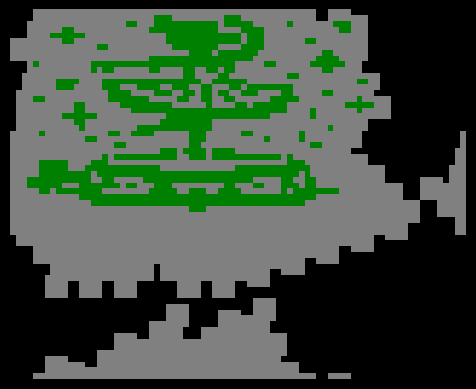

Test Example III passed, for partIII.
Success


In [54]:
from test_utilities import test

test_cases = [
    # cSpell:disable
    {
        'name': 'Example I',
        'notes': """
            .......
            .......
            .......
            .#.@...
            .......
            .......
            .......
         """,
        'expected': 87,
    },
    {
        'name': 'Example II',
        'notes': """
            #..#.......#...
            ...#...........
            ...#...........
            #######........
            ...#....#######
            ...#...@...#...
            ...#.......#...
            ...........#...
            ...........#...
            #..........#...
            ##......#######
         """,
        'expected': 239,
    },
    {
        'name': 'Example III',
        'notes': """
            ................................................................
            .........................###.........###........................
            ....................##...###########.#####......#.......###.....
            .........##.............############....####.............##.....
            .......######..............#############.###....................
            .........##................#############.###.......##...........
            ...............##...........########....####....................
            ...............................####.#######...........##........
            ........................##################...........####.......
            ....#.........#########################.....##......######......
            ..............#.##......##....##..##.##...............##........
            ..............................##....##..........##..............
            ........####....#################..######...................##..
            ........###.....###...####..###..##...##.########...............
            .................####....###..##.##.##..###....##.....##........
            ....##...........#######.....##..##..##......#####..........#...
            ...........##......#########......#....##.######..........#####.
            ...........##........###########################....#.......#...
            .........######............##################.......#...........
            ...........##.............#########.............................
            ............#.........#############....................#........
            .....#...........##..####......###......##........#.............
            .............##................###..........#.....#.............
            ..................##...........##...................##..........
            ..........................###.####.####.........................
            ................#.###########..###.############.#...............
            .....#####....###...............................###.............
            .....#####...#############......@......#############............
            .....#########.###################################.#............
            ...###########..##.....###################.....##..##...........
            ...######...#######.##...###.........##...##...###.##...........
            .....##.########........#####..###..####.......#.########.......
            ............#########################################...........
            ..............#####################################.............
            ...............................###..............................
            ................................................................
         """,
        # 'debug': True,
        'display_last': True,
        'expected': 1539,
    },
    # cSpell:enable
]


class SoundTemplateIII(SoundTemplateII):
    POSSIBLE_STEPS = (
        (-1, 0),
        (-1, 0),
        (-1, 0),
        (0, 1),
        (0, 1),
        (0, 1),
        (1, 0),
        (1, 0),
        (1, 0),
        (0, -1),
        (0, -1),
        (0, -1),
    )


@test(tests=test_cases[:])
def partIII(notes: str, display_last: bool = False, debug: bool = False) -> int:
    st = SoundTemplateIII(notes)
    return st.steps_sound_surrounded_vocal_bones(display_last, debug)

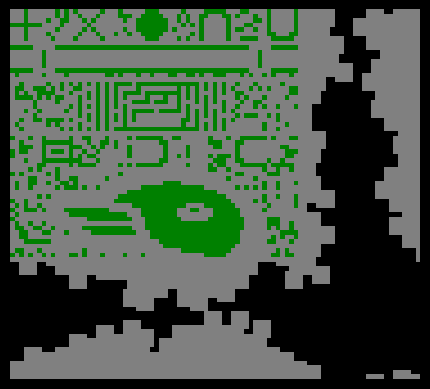

Part III: 2501


In [55]:
with open('./inputs/everybody_codes_e3_q02_p3.txt') as f:
    notes3 = f.read()


print(f'Part III: {partIII(notes3, display_last=True)}')

<div style="color:lime;width:25%;text-align:center">Quack yeah!</div>
<br/>

![happy quack](./images/happy_quack.svg)
